# Dataset Inspection: dataset-labeled-anon-ip.csv

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)

DATA_PATH = '../../../data/cscas/dataset-labeled-anon-ip.csv'

## 1. Load & Basic Info

In [2]:
df = pd.read_csv(DATA_PATH, parse_dates=['Timestamp'])
print(f'Shape: {df.shape}')
print(f'Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')

Shape: (1395324, 47)
Memory: 766.7 MB


In [3]:
df.dtypes

Timestamp                      datetime64[ns, UTC+02:00]
SignatureText                                     object
SignatureID                                        int64
SignatureMatchesPerDay                           float64
AlertCount                                         int64
Proto                                              int64
ExtIP                                             object
ExtPort                                            int64
IntIP                                             object
IntPort                                            int64
Similarity                                       float64
Label                                              int64
SCAS                                               int64
AppProtoSimilarity                               float64
DnsRrnameSimilarity                              float64
DnsRrtypeSimilarity                              float64
EmailFromSimilarity                                int64
EmailStatusSimilarity          

In [4]:
df.head()

,Timestamp,SignatureText,SignatureID,SignatureMatchesPerDay,AlertCount,Proto,ExtIP,ExtPort,IntIP,IntPort,Similarity,Label,SCAS,AppProtoSimilarity,DnsRrnameSimilarity,DnsRrtypeSimilarity,EmailFromSimilarity,EmailStatusSimilarity,EmailToSimilarity,ExtIPSimilarity,ExtPortSimilarity,HttpContentTypeSimilarity,HttpHostnameSimilarity,HttpMethodSimilarity,HttpProtocolSimilarity,HttpRequestBodySimilarity,HttpResponseBodySimilarity,HttpStatusSimilarity,HttpUrlSimilarity,HttpUserAgentSimilarity,IntIPSimilarity,IntPortSimilarity,ProtoSimilarity,SignatureIDSimilarity,SmtpHeloSimilarity,SmtpMailFromSimilarity,SmtpRcptToSimilarity,SshClientProtoSimilarity,SshClientSoftwareSimilarity,SshServerProtoSimilarity,SshServerSoftwareSimilarity,TlsFingerprintSimilarity,TlsIssuerDnSimilarity,TlsJa3hashSimilarity,TlsSniSimilarity,TlsSubjectSimilarity,TlsVersionSimilarity
0,2022-01-20 00:00:03+02:00,GPL SNMP public access udp,2101411,140201.481767,4,17,extip1,57239,-1,161,0.998231,0,0,0.989388,-1.0,-1.0,-1,-1,-1,1.000000,1.00000,-1.0,-1.0,-1.0,-1.000000,-1.0,-1.0,-1.0,-1.000000,-1.000000,1.0,1.000000,1.0,1.0,-1,-1,-1,-1,-1,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
1,2022-01-20 00:00:13+02:00,GPL SNMP public access udp,2101411,140201.525122,1,17,extip2,32050,intip1,161,0.998249,0,0,0.989494,-1.0,-1.0,-1,-1,-1,1.000000,1.00000,-1.0,-1.0,-1.0,-1.000000,-1.0,-1.0,-1.0,-1.000000,-1.000000,1.0,1.000000,1.0,1.0,-1,-1,-1,-1,-1,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
2,2022-01-20 00:00:17+02:00,ET VOIP REGISTER Message Flood UDP,2009699,298.864011,1,17,extip3,9999,intip2,5060,0.505563,0,0,1.000000,-1.0,-1.0,-1,-1,-1,0.016690,0.01669,-1.0,-1.0,-1.0,-1.000000,-1.0,-1.0,-1.0,-1.000000,-1.000000,0.0,1.000000,1.0,1.0,-1,-1,-1,-1,-1,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
3,2022-01-20 00:00:31+02:00,ET EXPLOIT D-Link Devices Home Network Administration Pr...,2020899,841.202279,1,6,extip4,44774,intip3,80,0.725752,0,0,1.000000,-1.0,-1.0,-1,-1,-1,0.524855,1.00000,0.0,1.0,1.0,0.782562,0.0,1.0,0.0,0.900447,0.683009,1.0,0.995414,1.0,1.0,-1,-1,-1,-1,-1,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
4,2022-01-20 00:00:31+02:00,ET WEB_SERVER WGET Command Specifying Output in HTTP Hea...,2019309,841.311867,1,6,extip4,44774,intip3,80,0.725752,0,0,1.000000,-1.0,-1.0,-1,-1,-1,0.524855,1.00000,0.0,1.0,1.0,0.782560,0.0,1.0,0.0,0.900447,0.683007,1.0,0.995414,1.0,1.0,-1,-1,-1,-1,-1,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0


In [5]:
df['IntIP'].value_counts()

IntIP
-1           330352
intip17       26801
intip10       20372
intip196      17591
intip18       17434
              ...  
intip4135       122
intip4247       120
intip3191       120
intip4400         1
intip4401         1
Name: count, Length: 4402, dtype: int64

In [6]:
df['ExtIP'].value_counts().get('-1', 0)

0

In [7]:
df["AlertCount"].value_counts()

AlertCount
1       880995
2       193137
3        54131
4        32690
32       20393
         ...  
1492         1
1675         1
1859         1
1712         1
2155         1
Name: count, Length: 751, dtype: int64

## 2. Missing Values

In [8]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if missing.empty:
    print('No missing values')
else:
    print(missing)

No missing values


In [9]:
# -1 is used as sentinel for missing similarity features
sim_cols = [c for c in df.columns if c.endswith('Similarity')]
sentinel_counts = (df[sim_cols] == -1).sum().sort_values(ascending=False)
print('Columns with -1 (sentinel missing):')
print(sentinel_counts[sentinel_counts > 0])

Columns with -1 (sentinel missing):
SmtpMailFromSimilarity         1395323
SmtpRcptToSimilarity           1395323
EmailFromSimilarity            1395323
EmailStatusSimilarity          1395323
EmailToSimilarity              1395323
SmtpHeloSimilarity             1395323
SshClientProtoSimilarity       1395314
SshClientSoftwareSimilarity    1395314
SshServerProtoSimilarity       1395314
SshServerSoftwareSimilarity    1395314
TlsFingerprintSimilarity       1393404
TlsVersionSimilarity           1393404
TlsIssuerDnSimilarity          1393404
TlsSniSimilarity               1393404
TlsSubjectSimilarity           1393404
TlsJa3hashSimilarity           1393404
DnsRrtypeSimilarity            1170370
DnsRrnameSimilarity            1170370
HttpUserAgentSimilarity        1134699
HttpUrlSimilarity              1134699
HttpStatusSimilarity           1134699
HttpResponseBodySimilarity     1134699
HttpRequestBodySimilarity      1134699
HttpProtocolSimilarity         1134699
HttpMethodSimilarity        

## 3. Label Distribution

In [10]:
print('Label value counts:')
print(df['Label'].value_counts())
print(f'\nClass balance: {df["Label"].value_counts(normalize=True).round(4).to_dict()}')

Label value counts:
Label
0    1374372
1      20952
Name: count, dtype: int64

Class balance: {0: 0.985, 1: 0.015}


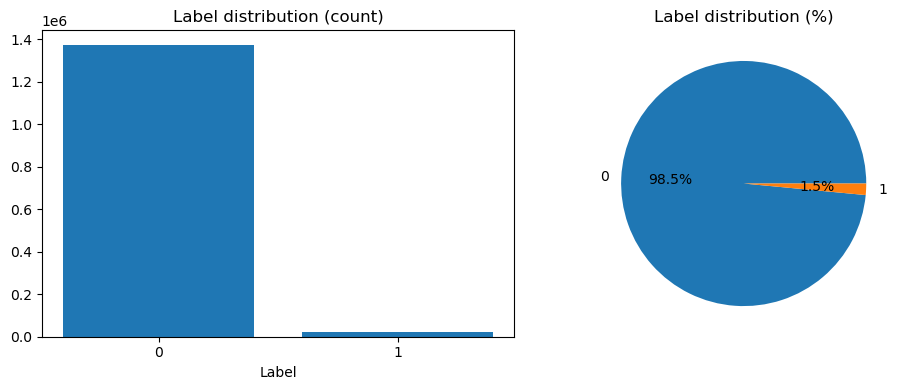

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

vc = df['Label'].value_counts()
axes[0].bar(vc.index.astype(str), vc.values)
axes[0].set_title('Label distribution (count)')
axes[0].set_xlabel('Label')

axes[1].pie(vc.values, labels=vc.index.astype(str), autopct='%1.1f%%')
axes[1].set_title('Label distribution (%)')

plt.tight_layout()
plt.show()

In [12]:
print('SCAS value counts:')
print(df['SCAS'].value_counts())

SCAS value counts:
SCAS
0    1322652
1      72672
Name: count, dtype: int64


## 4. Temporal Coverage

In [13]:
print(f'Time range: {df["Timestamp"].min()} → {df["Timestamp"].max()}')
print(f'Duration: {df["Timestamp"].max() - df["Timestamp"].min()}')

Time range: 2022-01-20 00:00:03+02:00 → 2022-03-20 23:59:58+02:00
Duration: 59 days 23:59:55


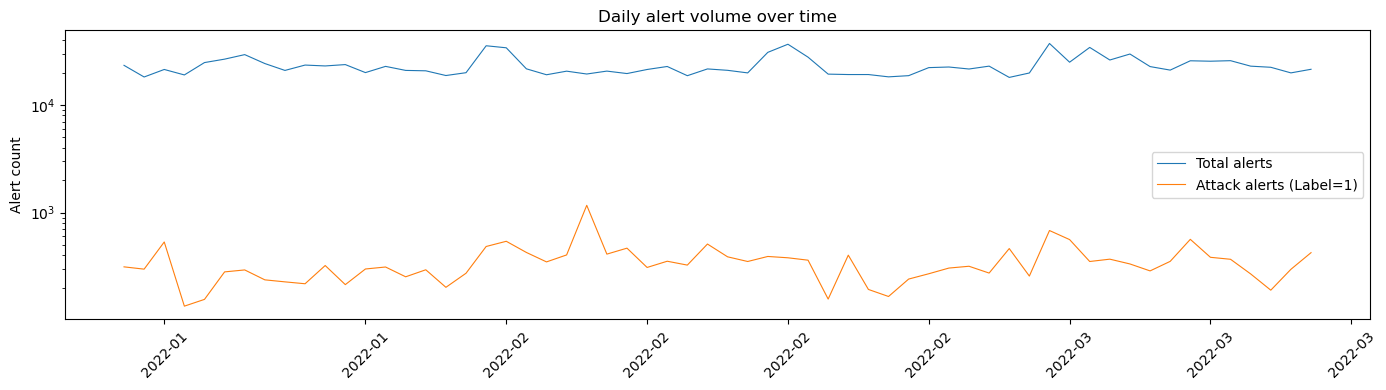

In [14]:
daily = df.set_index('Timestamp').resample('D').agg(
    total=('Label', 'count'),
    attacks=('Label', lambda x: (x == 1).sum())
)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily.index, daily['total'], label='Total alerts', linewidth=0.8)
ax.plot(daily.index, daily['attacks'], label='Attack alerts (Label=1)', linewidth=0.8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.set_title('Daily alert volume over time')
ax.set_ylabel('Alert count')
ax.set_yscale('log')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Signature Analysis

In [15]:
print(f'Unique signatures: {df["SignatureID"].nunique()}')
print(f'Unique signature texts: {df["SignatureText"].nunique()}')

# all unique sigs to file for inspection
df[['SignatureID', 'SignatureText']].drop_duplicates().sort_values('SignatureID').to_csv('unique_signatures.csv', index=False) 

Unique signatures: 587
Unique signature texts: 585


In [16]:
top_sigs = df.groupby(['SignatureID', 'SignatureText']).agg(
    count=('Label', 'count'),
    attacks=('Label', 'sum'),
    attack_rate=('Label', 'mean')
).sort_values('count', ascending=False).head(20)

top_sigs['attack_rate%'] = (top_sigs['attack_rate'] * 100).round(3)
top_sigs[['count', 'attacks', 'attack_rate%']]

,,count,attacks,attack_rate%
SignatureID,SignatureText,,,
2101411,GPL SNMP public access udp,592445,0,0.0
2101616,GPL DNS named version attempt,135622,0,0.0
2101867,GPL RPC xdmcp info query,135350,0,0.0
2842116,ETPRO USER_AGENTS Observed Suspicious UA (Mozilla/5.0),84112,0,0.0
2812543,ETPRO DOS Possible RPC Portmapper Scanning,82503,0,0.0
2101201,GPL WEB_SERVER 403 Forbidden,46384,0,0.0
2808084,ETPRO SNMP R7-2014-02 Ubee cable modem credential stealing attempt 1,35853,0,0.0
2027757,ET DNS Query for .to TLD,33233,0,0.0
2027758,ET DNS Query for .cc TLD,22108,0,0.0


In [17]:
# Top signatures by attack rate (min 10 alerts to filter noise)
all_sigs = df.groupby(['SignatureID', 'SignatureText']).agg(
    count=('Label', 'count'),
    attacks=('Label', 'sum'),
    attack_rate=('Label', 'mean')
).query('count >= 10').sort_values('attack_rate', ascending=False).head(20)

all_sigs['attack_rate%'] = (all_sigs['attack_rate'] * 100).round(1)
all_sigs[['count', 'attacks', 'attack_rate%']]

,,count,attacks,attack_rate%
SignatureID,SignatureText,,,
2025801,ET EXPLOIT file_put_contents php base64 encoded Remote Code Execution 1,10,10,100.0
2030667,ET WEB_SPECIFIC_APPS vBulletin RCE Inbound (CVE-2019-16759 Bypass),259,259,100.0
2027883,ET EXPLOIT FortiOS SSL VPN - Information Disclosure (CVE-2018-13379),16,16,100.0
2028372,ET JA3 Hash - Possible Malware - FiestaEK,44,44,100.0
2029150,ET JA3 Hash - Trojan.AndroidOS.Jocker.snt 1,64,64,100.0
2029616,ET EXPLOIT Zyxel NAS RCE Attempt Inbound (CVE-2020-9054) M1,160,160,100.0
2029976,ET EXPLOIT Netlink GPON Remote Code Execution Attempt (Inbound),26,26,100.0
2030193,ET WEB_SPECIFIC_APPS Attempted Symantec Secure Web Gateway RCE,64,64,100.0
2030309,ET EXPLOIT Wireless IP Camera (P2) WIFICAM Remote Code Execution,175,175,100.0


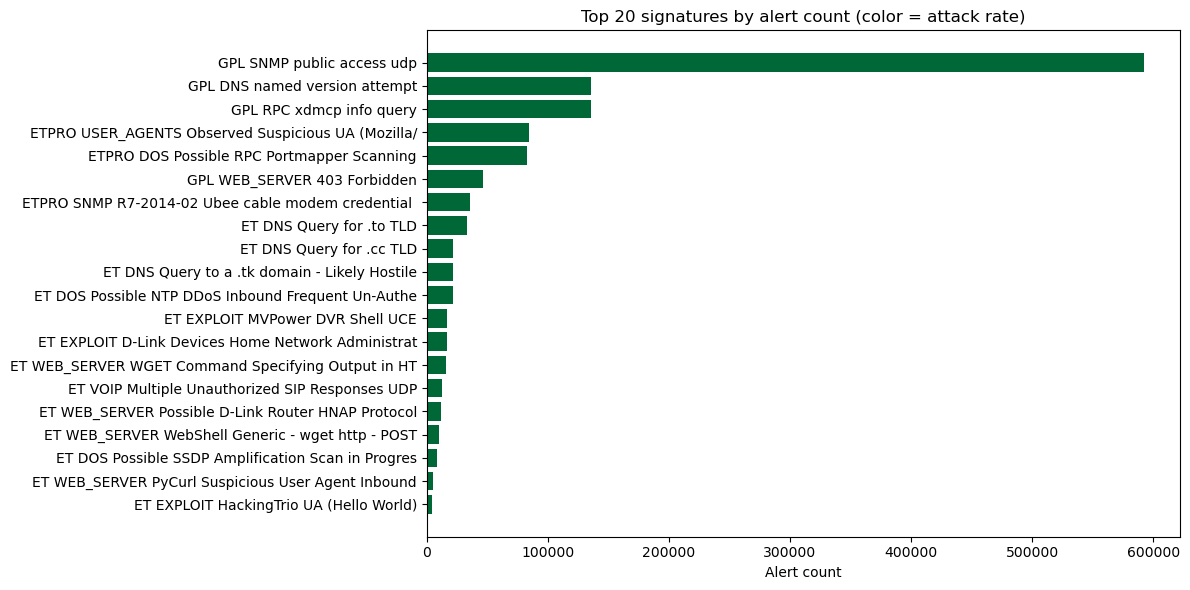

In [18]:
# Top signatures by count, colored by attack rate
top20 = top_sigs.reset_index()
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top20['SignatureText'].str[:50], top20['count'], color=plt.cm.RdYlGn_r(top20['attack_rate']))
ax.set_xlabel('Alert count')
ax.set_title('Top 20 signatures by alert count (color = attack rate)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 6. Protocol & Port Distribution

In [19]:
print('Protocol value counts (top 10):')
print(df['Proto'].value_counts().head(10))

Protocol value counts (top 10):
Proto
 17    1128587
 6      266497
-1         129
 1         111
Name: count, dtype: int64


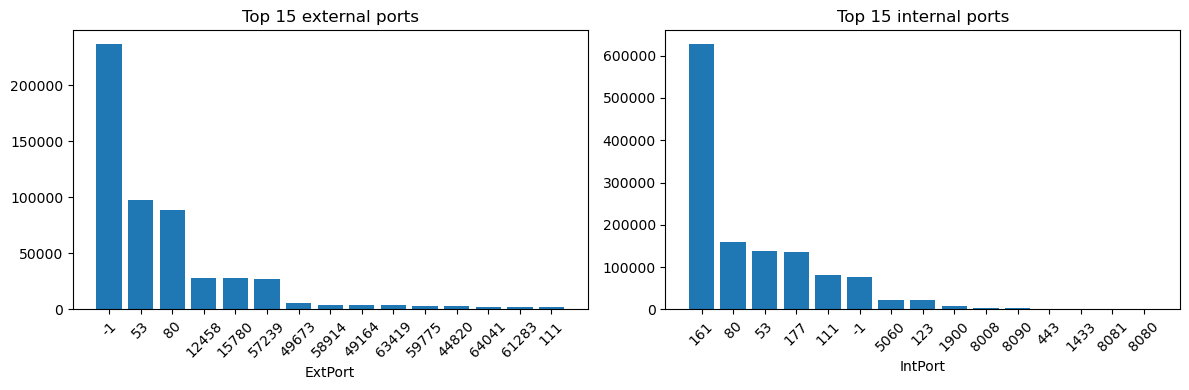

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ExtPort
top_ext = df['ExtPort'].value_counts().head(15)
axes[0].bar(top_ext.index.astype(str), top_ext.values)
axes[0].set_title('Top 15 external ports')
axes[0].set_xlabel('ExtPort')
axes[0].tick_params(axis='x', rotation=45)

# IntPort
top_int = df['IntPort'].value_counts().head(15)
axes[1].bar(top_int.index.astype(str), top_int.values)
axes[1].set_title('Top 15 internal ports')
axes[1].set_xlabel('IntPort')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 7. Similarity Feature Overview

In [21]:
# Replace -1 with NaN for stats on real similarity values
sim_df = df[sim_cols].replace(-1, np.nan)
sim_stats = sim_df.describe().T
sim_stats['coverage%'] = (sim_df.notna().mean() * 100).round(1)
sim_stats[['coverage%', 'mean', 'std', 'min', 'max']].sort_values('coverage%', ascending=False)

,coverage%,mean,std,min,max
Similarity,100.0,0.851473,0.176628,0.0,1.000000
SignatureIDSimilarity,100.0,0.974809,0.145852,0.0,1.000000
ProtoSimilarity,100.0,0.990791,0.067556,0.0,1.000000
IntPortSimilarity,100.0,0.962686,0.162492,0.0,1.000000
IntIPSimilarity,100.0,0.812993,0.352345,0.0,1.000000
AppProtoSimilarity,100.0,0.973877,0.117820,0.0,1.000000
ExtIPSimilarity,100.0,0.651323,0.439495,0.0,1.000000
ExtPortSimilarity,100.0,0.886974,0.304143,0.0,1.000000
HttpRequestBodySimilarity,18.7,0.385069,0.465781,0.0,1.000000
HttpUrlSimilarity,18.7,0.527076,0.394853,0.0,1.000000


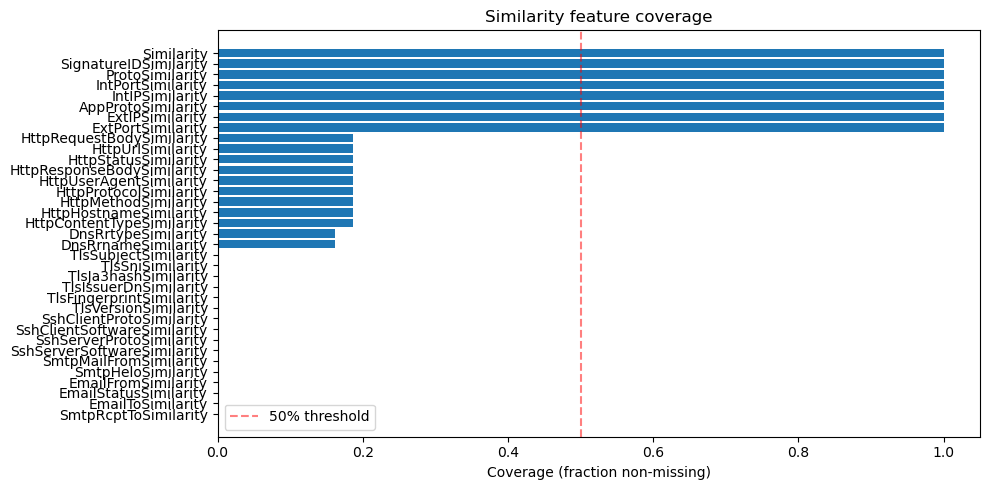

In [22]:
# Coverage heatmap
coverage = sim_df.notna().mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(coverage.index[::-1], coverage.values[::-1])
ax.set_xlabel('Coverage (fraction non-missing)')
ax.set_title('Similarity feature coverage')
ax.axvline(0.5, color='red', linestyle='--', alpha=0.5, label='50% threshold')
ax.legend()
plt.tight_layout()
plt.show()

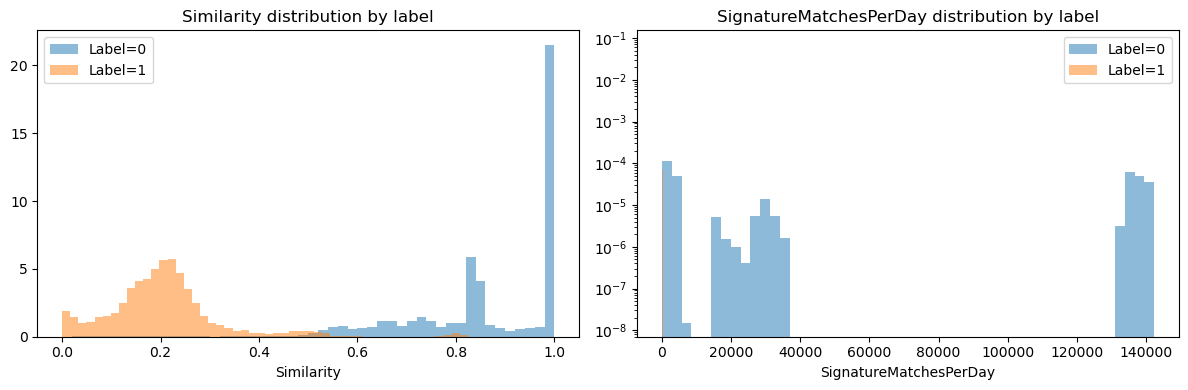

In [23]:
# Distribution of SCAS (aggregate similarity)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label, grp in df.groupby('Label'):
    axes[0].hist(grp['Similarity'], bins=50, alpha=0.5, density=True, label=f'Label={label}')
axes[0].set_title('Similarity distribution by label')
axes[0].set_xlabel('Similarity')
axes[0].legend()

for label, grp in df.groupby('Label'):
    axes[1].hist(grp['SignatureMatchesPerDay'], bins=50, alpha=0.5, density=True, label=f'Label={label}')
axes[1].set_title('SignatureMatchesPerDay distribution by label')
axes[1].set_xlabel('SignatureMatchesPerDay')
axes[1].set_yscale('log')
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Correlation of Similarity Features with Label

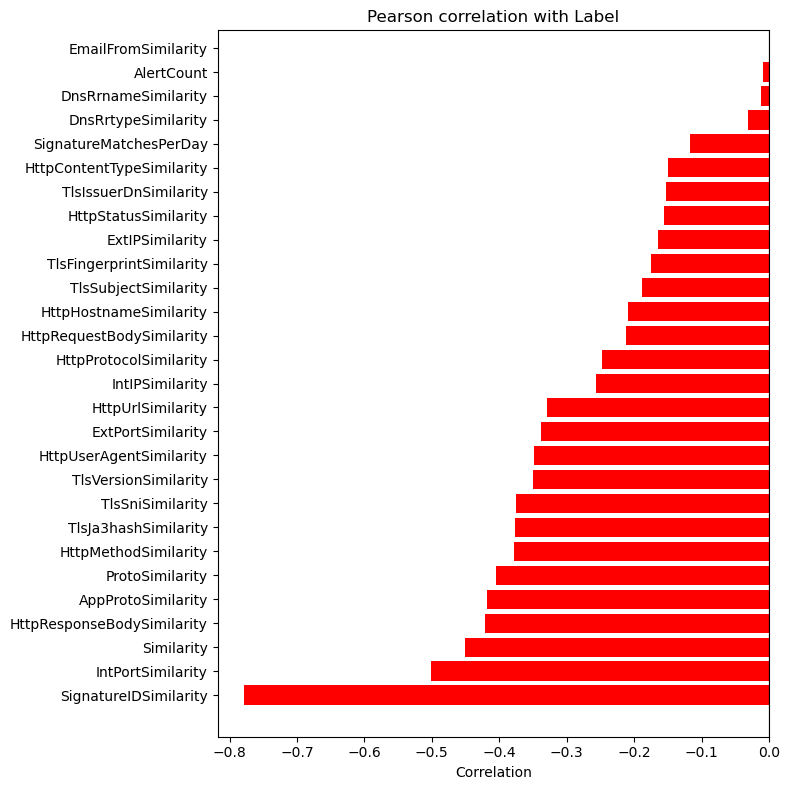

In [24]:
corr_cols = sim_cols + ['Similarity', 'SignatureMatchesPerDay', 'AlertCount']
corr_with_label = df[corr_cols + ['Label']].replace(-1, np.nan).corr()['Label'].drop('Label').sort_values()

fig, ax = plt.subplots(figsize=(8, 8))
colors = ['red' if v < 0 else 'steelblue' for v in corr_with_label.values]
ax.barh(corr_with_label.index, corr_with_label.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Pearson correlation with Label')
ax.set_xlabel('Correlation')
plt.tight_layout()
plt.show()

## 9. Quick Sanity Checks

In [25]:
print('Duplicate rows:', df.duplicated().sum())
print('Timestamp is monotonic:', df['Timestamp'].is_monotonic_increasing)
print('Unique Label values:', sorted(df['Label'].unique()))
print('Unique SCAS values:', sorted(df['SCAS'].unique()))
print('IntIP unique count (anonymized):', df['IntIP'].nunique())
print('ExtIP unique count (anonymized):', df['ExtIP'].nunique())

Duplicate rows: 0
Timestamp is monotonic: True
Unique Label values: [np.int64(0), np.int64(1)]
Unique SCAS values: [np.int64(0), np.int64(1)]
IntIP unique count (anonymized): 4402
ExtIP unique count (anonymized): 45339


In [26]:
# Rows where IntIP == -1 (not captured)
print('Rows with IntIP == -1:', (df['IntIP'] == '-1').sum())

Rows with IntIP == -1: 330352


## 10. Tokenization

In [27]:
from thesis.preprocessing.suricata_tokenization import tokenize_signatures_df

df_tok = pd.read_csv('unique_signatures.csv')
results = tokenize_signatures_df(df_tok)

df_out = pd.DataFrame([
    {
        "signature_id": s.signature_id,
        "ruleset": s.ruleset,
        "category": s.category,
        "description": s.description,
        "cve_refs": "|".join(sorted(s.cve_refs)),
        "qualifiers": "|".join(sorted(s.qualifiers)),
        "tokens": "|".join(sorted(s.tokens)),
    }
    for s in results
])

df_out.to_csv("tokenized_signatures2.csv", index=False)


## Do alert groups hit different IntIPS more often than just one?

In [28]:
# df was overwritten by the tokenization step above (df = unique_signatures.csv); reload the original dataset
df = pd.read_csv(DATA_PATH, parse_dates=['Timestamp'])

In [29]:
df['IntIP'].value_counts()

IntIP
-1           330352
intip17       26801
intip10       20372
intip196      17591
intip18       17434
              ...  
intip4135       122
intip4247       120
intip3191       120
intip4400         1
intip4401         1
Name: count, Length: 4402, dtype: int64

In [30]:
# IntIP == -1 means the (signature, ExtIP) session touched more than one internal IP.
# If that's a small set of broad scanning signatures fanning out over many IPs (rather
# than genuinely diverse multi-signature behavior), these rows are low-value noise.
neg1 = df[df['IntIP'] == '-1']
print(f"Rows with IntIP == -1: {len(neg1)} ({len(neg1)/len(df):.1%} of all rows)")
print(f"Distinct signatures among IntIP == -1 rows: {neg1['SignatureID'].nunique()} (of {df['SignatureID'].nunique()} total)")

vc = neg1['SignatureID'].value_counts()
print(f"\nShare of IntIP=-1 rows covered by top 1 signature:  {vc.iloc[0] / len(neg1):.1%}")
print(f"Share of IntIP=-1 rows covered by top 5 signatures:  {vc.head(5).sum() / len(neg1):.1%}")
print(f"Share of IntIP=-1 rows covered by top 10 signatures: {vc.head(10).sum() / len(neg1):.1%}")

Rows with IntIP == -1: 330352 (23.7% of all rows)
Distinct signatures among IntIP == -1 rows: 301 (of 587 total)

Share of IntIP=-1 rows covered by top 1 signature:  49.4%
Share of IntIP=-1 rows covered by top 5 signatures:  86.9%
Share of IntIP=-1 rows covered by top 10 signatures: 93.9%


In [31]:
sig_text = neg1.drop_duplicates('SignatureID').set_index('SignatureID')['SignatureText']
top15 = vc.head(15).rename('count').to_frame()
top15['share%'] = (top15['count'] / len(neg1) * 100).round(1)
top15['signature'] = top15.index.map(sig_text)
print(top15[['count', 'share%', 'signature']].to_string())

print(f"\nDistinct ExtIP among IntIP=-1 rows: {neg1['ExtIP'].nunique()}")
print(f"\nLabel distribution among IntIP=-1 rows:\n{neg1['Label'].value_counts()}")

              count  share%                                                                         signature
SignatureID                                                                                                  
2101411      163351    49.4                                                        GPL SNMP public access udp
2101867       59340    18.0                                                          GPL RPC xdmcp info query
2101616       46042    13.9                                                     GPL DNS named version attempt
2812543        9903     3.0                                        ETPRO DOS Possible RPC Portmapper Scanning
2842116        8505     2.6                            ETPRO USER_AGENTS Observed Suspicious UA (Mozilla/5.0)
2808084        6474     2.0              ETPRO SNMP R7-2014-02 Ubee cable modem credential stealing attempt 1
2027757        5405     1.6                                                          ET DNS Query for .to TLD
2017919   

## 11. Grouped Dataset — (IntIP, time window) binning (`cscas_target_window`)

Baskets are keyed by (internal target IP, 1h window) instead of one basket per CSV row/signature (`cscas_pregrouped`), so a basket can span multiple distinct signatures fired against the same target. Rows with `IntIP == -1` (session touched multiple internal IPs, not resolvable to one target) are excluded — see `group_cscas_rows_by_target_window` in `src/thesis/grouping/group_alerts.py`.

### Alert volume per internal IP over time

Before picking a time-window / session-gap scheme, look at how raw traffic against individual internal IPs is actually distributed over time — bursty with clear gaps, or roughly continuous? This uses the raw CSV rows (`df`), not the pre-built `cscas_target_window` baskets, since we're informing that design choice.

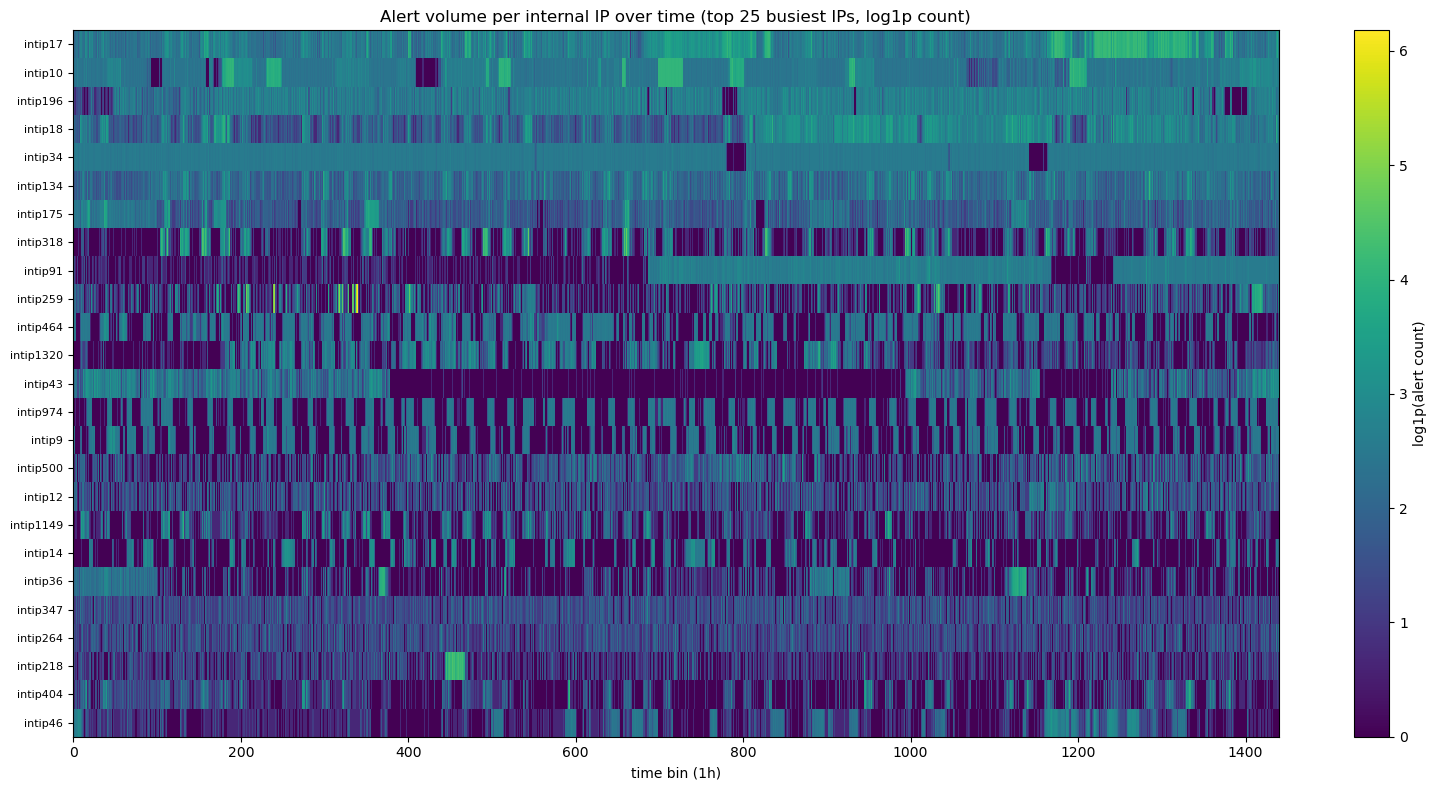

In [32]:
# Heatmap: alert volume per (internal IP, hourly time bin), for the busiest IPs.
# IntIP == -1 excluded (not a single target -- see section 11 intro).
N_TOP_IPS = 25
BIN = '1h'

df_valid = df[df['IntIP'] != '-1'].copy()
top_ips = df_valid['IntIP'].value_counts().head(N_TOP_IPS).index.tolist()

ts_by_ip = (
    df_valid[df_valid['IntIP'].isin(top_ips)]
    .groupby(['IntIP', pd.Grouper(key='Timestamp', freq=BIN)])
    .size()
    .unstack('IntIP')
    .fillna(0)
    .reindex(columns=top_ips)  # keep busiest-first row order in the heatmap
)

fig, ax = plt.subplots(figsize=(16, 8))
im = ax.imshow(
    np.log1p(ts_by_ip.T.values),
    aspect='auto',
    cmap='viridis',
    interpolation='nearest',
)
ax.set_yticks(range(len(top_ips)))
ax.set_yticklabels(top_ips, fontsize=8)
ax.set_xlabel(f'time bin ({BIN})')
ax.set_title(f'Alert volume per internal IP over time (top {N_TOP_IPS} busiest IPs, log1p count)')
fig.colorbar(im, ax=ax, label='log1p(alert count)')
plt.tight_layout()
plt.show()

/var/folders/69/6nn2sm8d7qq0p98t_qgp1ckr0000gn/T/ipykernel_72481/3688335518.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .groupby(['IntIP', pd.Grouper(key='Timestamp', freq='6H')])


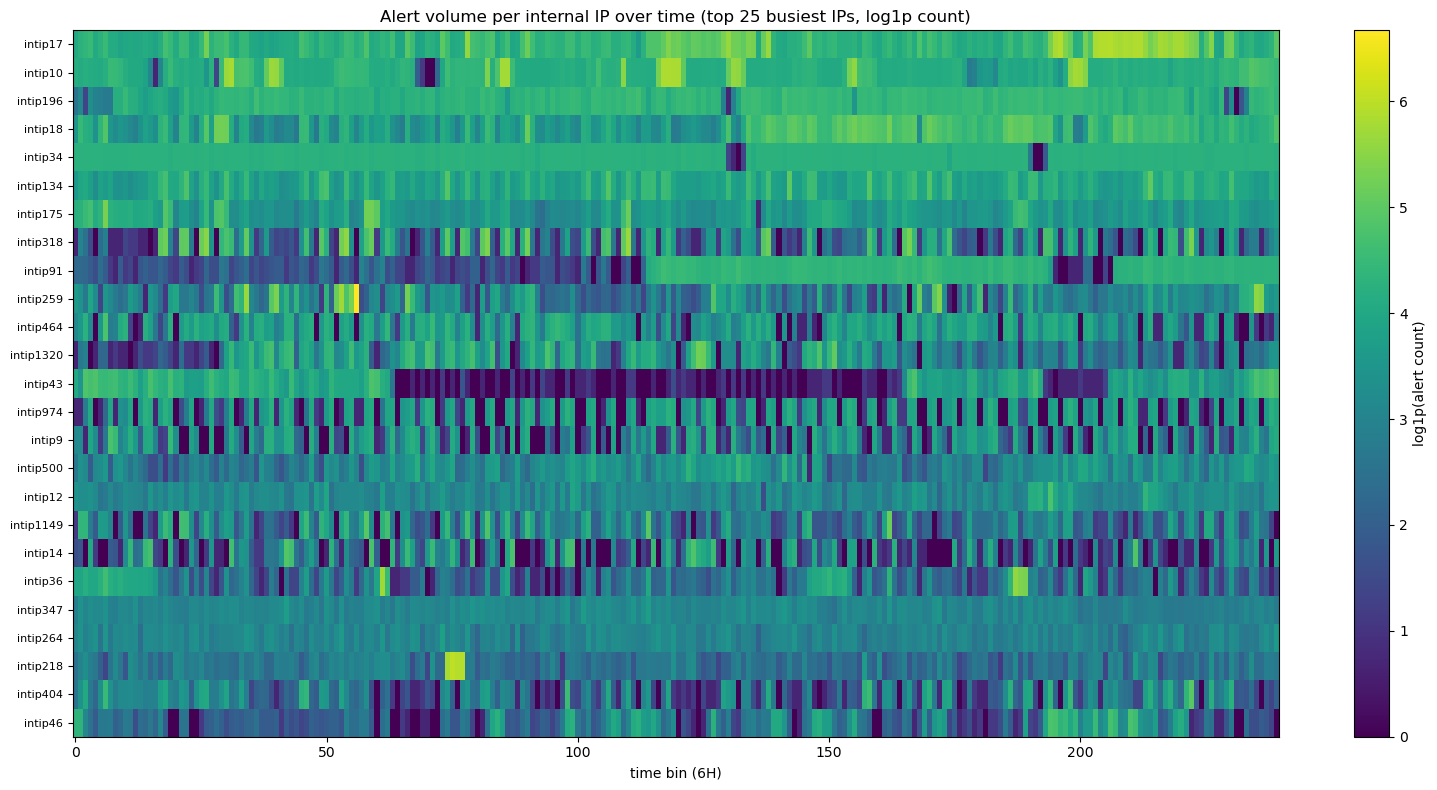

In [33]:
ts_by_ip = (
    df_valid[df_valid['IntIP'].isin(top_ips)]
    .groupby(['IntIP', pd.Grouper(key='Timestamp', freq='6H')])
    .size()
    .unstack('IntIP')
    .fillna(0)
    .reindex(columns=top_ips)  # keep busiest-first row order in the heatmap
)

fig, ax = plt.subplots(figsize=(16, 8))
im = ax.imshow(
    np.log1p(ts_by_ip.T.values),
    aspect='auto',
    cmap='viridis',
    interpolation='nearest',
)
ax.set_yticks(range(len(top_ips)))
ax.set_yticklabels(top_ips, fontsize=8)
ax.set_xlabel(f'time bin (6H)')
ax.set_title(f'Alert volume per internal IP over time (top {N_TOP_IPS} busiest IPs, log1p count)')
fig.colorbar(im, ax=ax, label='log1p(alert count)')
plt.tight_layout()
plt.show()

In [34]:
import json

In [37]:
target_window_group_file = "../../../artifacts/cache/cscas/groups/cscas_target_window_w21600s/alert_groups/alert_groups_raw.json"

with open(target_window_group_file, 'r') as f:
    tw_groups = json.load(f)

print(f'Loaded {len(tw_groups)} target-window alert_groups')

Loaded 491479 target-window alert_groups


In [38]:
tw_df = pd.DataFrame([
    {
        'group_id': g['group_id'],
        'int_ip': g['int_ip'],
        'n_alerts': g['n_alerts'],
        'n_rows': len(g['sorted_items']),
        'n_items': len(g['abs_items']),
        'group_label': g['group_label'],
        'start_ts': g['start_ts'],
        'end_ts': g['end_ts'],
    }
    for g in tw_groups
])

print(f'Baskets: {len(tw_df)}')
print(f'Distinct int_ip: {tw_df["int_ip"].nunique()}')
print()
print('group_label distribution:')
print(tw_df['group_label'].value_counts())
print()
print('n_rows (CSV rows aggregated per basket) — describe:')
print(tw_df['n_rows'].describe())

Baskets: 491479
Distinct int_ip: 4401

group_label distribution:
group_label
benign    484950
mixed       5294
attack      1235
Name: count, dtype: int64

n_rows (CSV rows aggregated per basket) — describe:
count    491479.000000
mean          2.166872
std           6.867262
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max         754.000000
Name: n_rows, dtype: float64


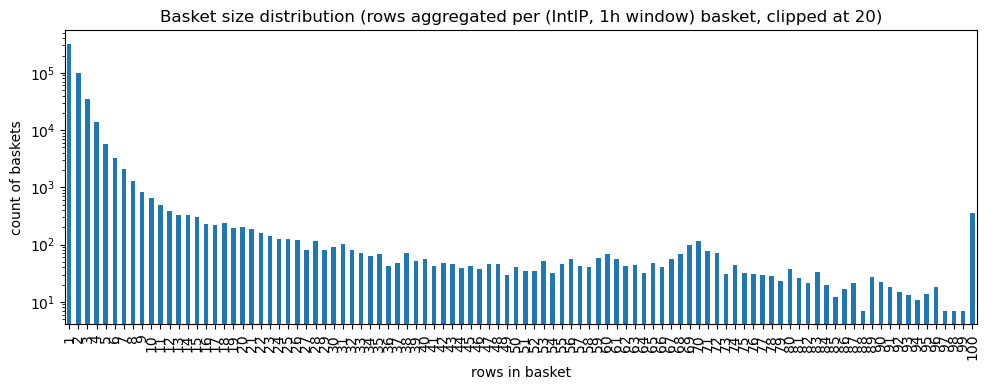

In [39]:
fig, ax = plt.subplots(figsize=(10, 4))
tw_df['n_rows'].clip(upper=100).value_counts().sort_index().plot(kind='bar', ax=ax)
ax.set_title('Basket size distribution (rows aggregated per (IntIP, 1h window) basket, clipped at 20)')
ax.set_xlabel('rows in basket')
ax.set_ylabel('count of baskets')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

### Are baskets actually multi-signature, or just the same signature repeated?

`n_rows > 1` alone doesn't mean a basket is interesting for co-occurrence mining — a target hit 11 times by the *same* signature in an hour is still a single-signature basket. Count distinct token-sets (i.e. distinct signatures) within each basket's `sorted_items`.

In [40]:
def n_distinct_signatures(g):
    return len({tuple(sorted(s)) for s in g['sorted_items']})

tw_df['n_distinct_sigs'] = [n_distinct_signatures(g) for g in tw_groups]

multi_row = tw_df[tw_df['n_rows'] > 1]
diverse = multi_row[multi_row['n_distinct_sigs'] > 1]

print(f"Baskets with >1 row: {len(multi_row)} ({len(multi_row) / len(tw_df):.1%} of all baskets)")
print(f"Baskets genuinely spanning >1 distinct signature: {len(diverse)} ({len(diverse) / len(tw_df):.1%} of all baskets)")
print(f"  = {len(diverse) / len(multi_row):.1%} of multi-row baskets")
print()
print('Distribution of n_distinct_sigs among multi-row baskets:')
print(multi_row['n_distinct_sigs'].value_counts().sort_index().head(15))

Baskets with >1 row: 169391 (34.5% of all baskets)
Baskets genuinely spanning >1 distinct signature: 115739 (23.5% of all baskets)
  = 68.3% of multi-row baskets

Distribution of n_distinct_sigs among multi-row baskets:
n_distinct_sigs
1     53652
2     85918
3     15943
4      6453
5      3509
6      1866
7       922
8       489
9       195
10       96
11       57
12       19
13       19
14       57
15       58
Name: count, dtype: int64


### Cross-signature category co-occurrence

Which pairs of signature categories (`cat:EXPLOIT`, `cat:WEB_SERVER`, ...) actually co-occur against the same target within an hour? This is the pattern `cscas_pregrouped` structurally cannot surface — every basket there is one signature, so no itemset can ever contain two categories.

In [41]:
from itertools import combinations
from collections import Counter

pair_counts = Counter()
for g in tw_groups:
    cats = set()
    for row_tokens in g['sorted_items']:
        cats.update(t for t in row_tokens if t.startswith('cat:'))
    if len(cats) >= 2:
        for pair in combinations(sorted(cats), 2):
            pair_counts[pair] += 1

n_total = len(tw_groups)
top_pairs = pd.DataFrame(
    [(a, b, c, c / n_total) for (a, b), c in pair_counts.most_common(20)],
    columns=['category_a', 'category_b', 'count', 'support'],
)
top_pairs

,category_a,category_b,count,support
0,cat:DOS,cat:SNMP,29535,0.060094
1,cat:DNS,cat:SNMP,26050,0.053003
2,cat:RPC,cat:SNMP,22799,0.046389
3,cat:EXPLOIT,cat:WEB_SERVER,17400,0.035403
4,cat:DOS,cat:RPC,9021,0.018355
5,cat:DNS,cat:DOS,8472,0.017238
6,cat:EXPLOIT,cat:SNMP,8035,0.016349
7,cat:SNMP,cat:WEB_SERVER,6956,0.014153
8,cat:DNS,cat:RPC,5975,0.012157
9,cat:DNS,cat:EXPLOIT,2501,0.005089


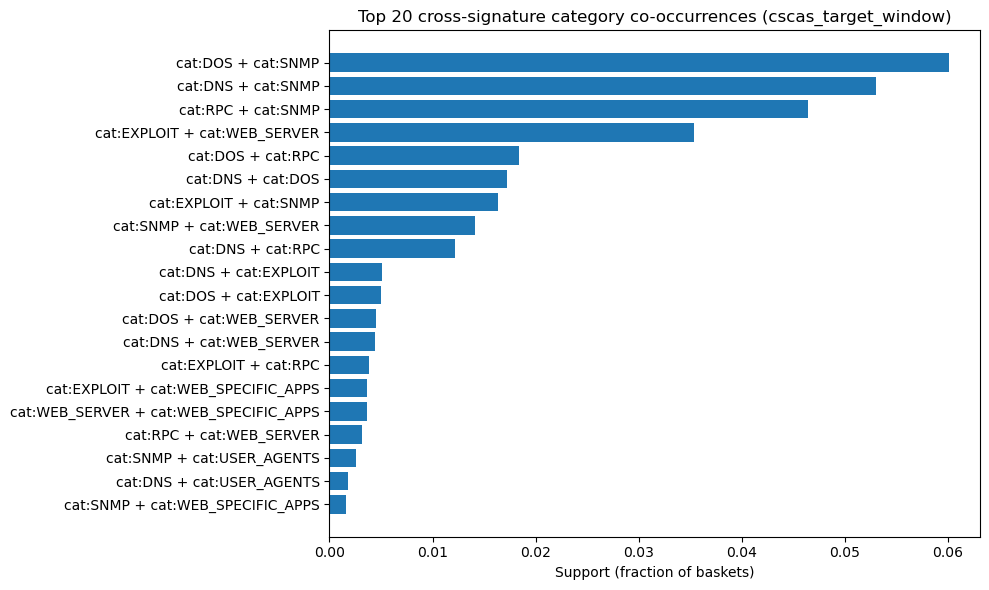

In [42]:
fig, ax = plt.subplots(figsize=(10, 6))
labels = [f"{a} + {b}" for a, b in zip(top_pairs['category_a'], top_pairs['category_b'])]
ax.barh(labels[::-1], top_pairs['support'].values[::-1])
ax.set_xlabel('Support (fraction of baskets)')
ax.set_title('Top 20 cross-signature category co-occurrences (cscas_target_window)')
plt.tight_layout()
plt.show()

In [43]:
# Eyeball one genuinely multi-signature basket
diverse_groups = [g for g in tw_groups if n_distinct_signatures(g) > 1]
sample = diverse_groups[0]

print('int_ip:', sample['int_ip'])
print('label:', sample['group_label'])
print('n_rows:', len(sample['sorted_items']))
print('abs_items (union):', sorted(sample['abs_items']))
print()
print('sorted_items (one row per original signature, timestamp order):')
for row_tokens in sample['sorted_items']:
    print(' -', sorted(row_tokens))

int_ip: intip2
label: benign
n_rows: 3
abs_items (union): ['access', 'access_udp', 'cat:DNS', 'cat:SNMP', 'cat:VOIP', 'flood', 'flood_udp', 'message', 'message_flood', 'named', 'public', 'public_access', 'register', 'register_message', 'udp', 'version']

sorted_items (one row per original signature, timestamp order):
 - ['cat:VOIP', 'flood', 'flood_udp', 'message', 'message_flood', 'register', 'register_message', 'udp']
 - ['cat:DNS', 'named', 'version']
 - ['access', 'access_udp', 'cat:SNMP', 'public', 'public_access', 'udp']


## 12. Window-size sensitivity analysis

`window_seconds` in `cscas_target_window` is a hyperparameter, not a fixed design choice — compare basket statistics across the window sizes ingested so far (auto-discovered from `artifacts/cache/cscas/groups/cscas_target_window_w*s/`) to characterize the tradeoff:

- larger windows → more time for distinct signatures to land in the same basket (more mining signal), but also more opportunity for unrelated benign/attack traffic against the same target to get pooled together (label contamination), and a growing risk of a small number of continuously-scanned hosts forming disproportionately large "mega-baskets" that dominate support statistics.

In [44]:
import re
from pathlib import Path

GROUPS_DIR = Path('../../../artifacts/cache/cscas/groups')


def discover_target_window_caches(groups_dir=GROUPS_DIR):
    """Find all cscas_target_window_w<seconds>s cache dirs, keyed by window_seconds."""
    caches = {}
    for d in sorted(groups_dir.glob('cscas_target_window_w*s')):
        m = re.match(r'cscas_target_window_w([\d_]+)s$', d.name)
        if not m:
            continue
        window_seconds = float(m.group(1).replace('_', '.'))
        path = d / 'alert_groups' / 'alert_groups_raw.json'
        if path.exists():
            caches[window_seconds] = path
    return dict(sorted(caches.items()))


def format_window_label(window_seconds):
    if window_seconds >= 3600:
        return f'{window_seconds / 3600:g}h'
    return f'{window_seconds / 60:g}m'


window_caches = discover_target_window_caches()
print('Discovered window sizes:', [format_window_label(w) for w in window_caches])

Discovered window sizes: ['30m', '1h', '6h', '12h']


In [45]:
def analyze_window_groups(groups):
    """Summary stats + cross-signature category-pair support for one window size's alert_groups."""
    n = len(groups)
    n_rows = np.array([len(g['sorted_items']) for g in groups])
    n_distinct = np.array([len({tuple(sorted(s)) for s in g['sorted_items']}) for g in groups])
    labels = pd.Series([g['group_label'] for g in groups])
    multi_row_mask = n_rows > 1
    diverse_mask = multi_row_mask & (n_distinct > 1)

    pair_counts = Counter()
    for g in groups:
        cats = set()
        for row_tokens in g['sorted_items']:
            cats.update(t for t in row_tokens if t.startswith('cat:'))
        if len(cats) >= 2:
            for pair in combinations(sorted(cats), 2):
                pair_counts[pair] += 1

    summary = {
        'n_baskets': n,
        'n_distinct_int_ip': len({g['int_ip'] for g in groups}),
        'median_rows_per_basket': float(np.median(n_rows)),
        'mean_rows_per_basket': float(n_rows.mean()),
        'max_rows_per_basket': int(n_rows.max()),
        'pct_multi_row': float(multi_row_mask.mean() * 100),
        'pct_genuinely_multi_signature': float(diverse_mask.mean() * 100),
        'pct_benign': float((labels == 'benign').mean() * 100),
        'pct_attack': float((labels == 'attack').mean() * 100),
        'pct_mixed': float((labels == 'mixed').mean() * 100),
    }
    pair_support = {pair: count / n for pair, count in pair_counts.items()}
    return summary, pair_support, n_rows


window_summaries = {}
window_pair_supports = {}
window_basket_sizes = {}

for window_seconds, path in window_caches.items():
    label = format_window_label(window_seconds)
    print(f'Loading window={label} ({path}) ...')
    with open(path) as f:
        groups = json.load(f)
    summary, pair_support, basket_sizes = analyze_window_groups(groups)
    window_summaries[label] = summary
    window_pair_supports[label] = pair_support
    window_basket_sizes[label] = basket_sizes
    del groups
    print(f'  {summary["n_baskets"]} baskets, {summary["pct_genuinely_multi_signature"]:.1f}% genuinely multi-signature')

window_summary_df = pd.DataFrame(window_summaries).T
window_summary_df

Loading window=30m (../../../artifacts/cache/cscas/groups/cscas_target_window_w1800s/alert_groups/alert_groups_raw.json) ...
  729135 baskets, 7.0% genuinely multi-signature
Loading window=1h (../../../artifacts/cache/cscas/groups/cscas_target_window_w3600s/alert_groups/alert_groups_raw.json) ...
  681880 baskets, 8.7% genuinely multi-signature
Loading window=6h (../../../artifacts/cache/cscas/groups/cscas_target_window_w21600s/alert_groups/alert_groups_raw.json) ...
  491479 baskets, 23.5% genuinely multi-signature
Loading window=12h (../../../artifacts/cache/cscas/groups/cscas_target_window_w43200s/alert_groups/alert_groups_raw.json) ...
  374131 baskets, 38.4% genuinely multi-signature


,n_baskets,n_distinct_int_ip,median_rows_per_basket,mean_rows_per_basket,max_rows_per_basket,pct_multi_row,pct_genuinely_multi_signature,pct_benign,pct_attack,pct_mixed
30m,729135.0,4401.0,1.0,1.460596,318.0,15.516057,7.025037,98.693246,0.753633,0.553121
1h,681880.0,4401.0,1.0,1.561817,482.0,16.240248,8.696398,98.718250,0.643662,0.638089
6h,491479.0,4401.0,1.0,2.166872,754.0,34.465562,23.549124,98.671561,0.251282,1.077157
12h,374131.0,4401.0,2.0,2.846522,767.0,52.300397,38.434399,98.455087,0.130970,1.413943


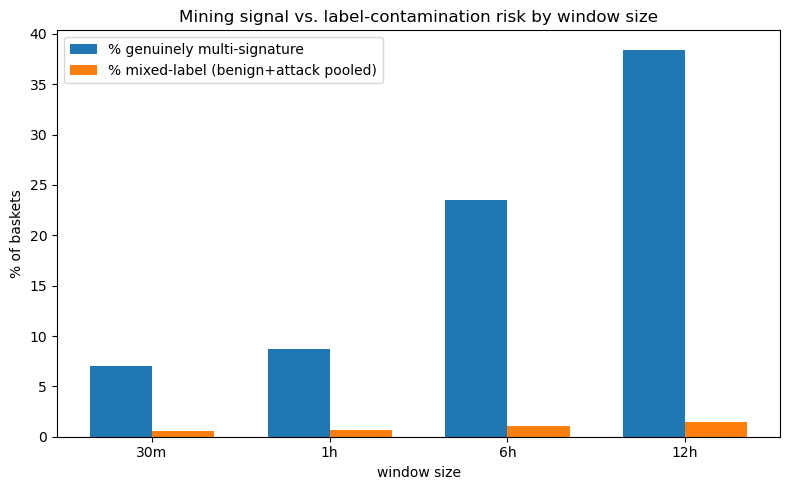

In [46]:
# Signal (genuine multi-signature baskets) vs. contamination risk (mixed-label baskets) by window size
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(window_summary_df))
width = 0.35
ax.bar(x - width / 2, window_summary_df['pct_genuinely_multi_signature'], width, label='% genuinely multi-signature')
ax.bar(x + width / 2, window_summary_df['pct_mixed'], width, label='% mixed-label (benign+attack pooled)')
ax.set_xticks(x)
ax.set_xticklabels(window_summary_df.index)
ax.set_xlabel('window size')
ax.set_ylabel('% of baskets')
ax.set_title('Mining signal vs. label-contamination risk by window size')
ax.legend()
plt.tight_layout()
plt.show()

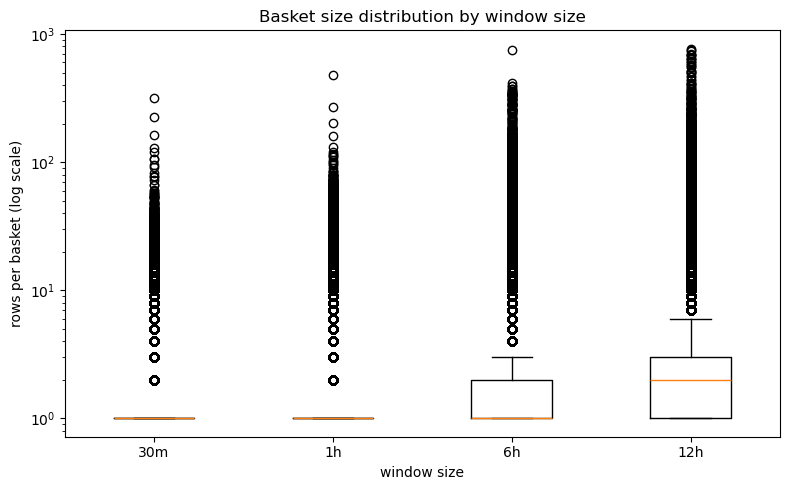

Max rows in a single basket, by window size:
30m    318.0
1h     482.0
6h     754.0
12h    767.0
Name: max_rows_per_basket, dtype: float64


In [47]:
# Basket-size distribution by window size (log scale) — watch for "mega-basket" growth
fig, ax = plt.subplots(figsize=(8, 5))
labels_ordered = list(window_summary_df.index)
ax.boxplot(
    [window_basket_sizes[label] for label in labels_ordered],
    tick_labels=labels_ordered,
    showfliers=True,
)
ax.set_yscale('log')
ax.set_xlabel('window size')
ax.set_ylabel('rows per basket (log scale)')
ax.set_title('Basket size distribution by window size')
plt.tight_layout()
plt.show()

print('Max rows in a single basket, by window size:')
print(window_summary_df['max_rows_per_basket'])

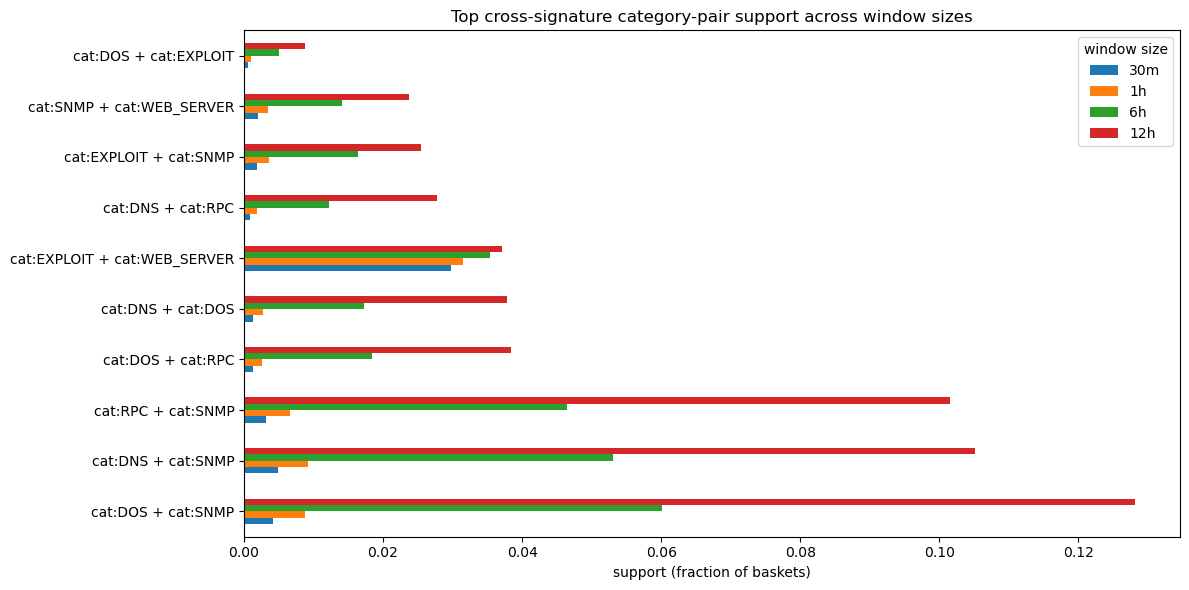

In [48]:
# Does the actual mining signal (cross-signature category co-occurrence support) grow or
# just dilute as the window widens? Compare the strongest pairs across window sizes.
all_pairs = set()
for supports in window_pair_supports.values():
    all_pairs.update(supports.keys())

pair_df = pd.DataFrame({
    label: {pair: window_pair_supports[label].get(pair, 0.0) for pair in all_pairs}
    for label in window_summary_df.index
})
top_pairs_overall = pair_df.max(axis=1).sort_values(ascending=False).head(10).index
plot_df = pair_df.loc[top_pairs_overall]

fig, ax = plt.subplots(figsize=(12, 6))
plot_df.plot(kind='barh', ax=ax)
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels([f'{a} + {b}' for a, b in plot_df.index])
ax.set_xlabel('support (fraction of baskets)')
ax.set_title('Top cross-signature category-pair support across window sizes')
ax.legend(title='window size')
plt.tight_layout()
plt.show()

## 13. Detection latency: fixed window vs. session-gap

Basket *duration* (`end_ts - start_ts`) is not the same thing as detection latency. Under a **fixed window**, a basket can only be reported at the window's calendar boundary, regardless of content — so the delay from a basket's first row to when the system could report it is:

`delay = window_boundary_end - start_ts` (ranges from ~0 to `window_seconds`, depending only on where `start_ts` happens to fall in the window — not on how active the target was).

Under the **session-gap** scheme, a basket can only be reported once the target has gone quiet for `session_timeout` (so we know no more rows are coming), or once it's forced closed at the `session_length` cap:

`delay = min((end_ts - start_ts) + session_timeout, session_length)`.

This is the metric that actually answers "how long would a real deployment have to wait" — not the nominal window size.

In [50]:
def discover_target_session_caches(groups_dir=GROUPS_DIR):
    """Find all cscas_target_session_t<timeout>s_l<length>s cache dirs."""
    caches = {}
    for d in sorted(groups_dir.glob('cscas_target_session_t*s_l*s')):
        m = re.match(r'cscas_target_session_t([\d_]+)s_l([\d_]+)s$', d.name)
        if not m:
            continue
        session_timeout = float(m.group(1).replace('_', '.'))
        session_length = float(m.group(2).replace('_', '.'))
        path = d / 'alert_groups' / 'alert_groups_raw.json'
        if path.exists():
            caches[(session_timeout, session_length)] = path
    return dict(sorted(caches.items()))


def fixed_window_delays(groups, window_seconds):
    """Estimated reporting delay per basket under a fixed calendar window."""
    start_ts = np.array([g['start_ts'] for g in groups], dtype=np.int64)
    window_id = start_ts // int(window_seconds)
    boundary_end = (window_id + 1) * int(window_seconds)
    return boundary_end - start_ts


def session_gap_delays(groups, session_timeout, session_length):
    """Estimated reporting delay per basket under the session-gap scheme."""
    duration = np.array([g['end_ts'] - g['start_ts'] for g in groups], dtype=np.int64)
    return np.minimum(duration + session_timeout, session_length)


session_caches = discover_target_session_caches()
print('Discovered session-gap caches (timeout, length) in seconds:', list(session_caches.keys()))

Discovered session-gap caches (timeout, length) in seconds: [(1800.0, 21600.0)]


In [51]:
delay_distributions = {}  # label -> np.ndarray of per-basket delay (seconds)
delay_summary_rows = {}

for window_seconds, path in window_caches.items():
    label = f'fixed {format_window_label(window_seconds)}'
    print(f'Loading {label} ...')
    with open(path) as f:
        groups = json.load(f)
    delays = fixed_window_delays(groups, window_seconds)
    del groups
    delay_distributions[label] = delays
    delay_summary_rows[label] = {
        'n_baskets': len(delays),
        'mean_delay_s': delays.mean(),
        'median_delay_s': float(np.median(delays)),
        'p95_delay_s': float(np.percentile(delays, 95)),
        'max_delay_s': int(delays.max()),
    }

for (session_timeout, session_length), path in session_caches.items():
    label = f'session t={format_window_label(session_timeout)}/l={format_window_label(session_length)}'
    print(f'Loading {label} ...')
    with open(path) as f:
        groups = json.load(f)
    delays = session_gap_delays(groups, session_timeout, session_length)
    del groups
    delay_distributions[label] = delays
    delay_summary_rows[label] = {
        'n_baskets': len(delays),
        'mean_delay_s': delays.mean(),
        'median_delay_s': float(np.median(delays)),
        'p95_delay_s': float(np.percentile(delays, 95)),
        'max_delay_s': int(delays.max()),
    }

delay_summary_df = pd.DataFrame(delay_summary_rows).T
delay_summary_df

Loading fixed 30m ...
Loading fixed 1h ...
Loading fixed 6h ...
Loading fixed 12h ...
Loading session t=30m/l=6h ...


,n_baskets,mean_delay_s,median_delay_s,p95_delay_s,max_delay_s
fixed 30m,729135.0,945.929799,961.0,1729.0,1800.0
fixed 1h,681880.0,1890.327074,1921.0,3461.0,3600.0
fixed 6h,491479.0,12226.638837,12871.0,20935.0,21600.0
fixed 12h,374131.0,26144.665398,27862.0,42108.0,43200.0
session t=30m/l=6h,663612.0,1977.230785,1800.0,2690.0,21600.0


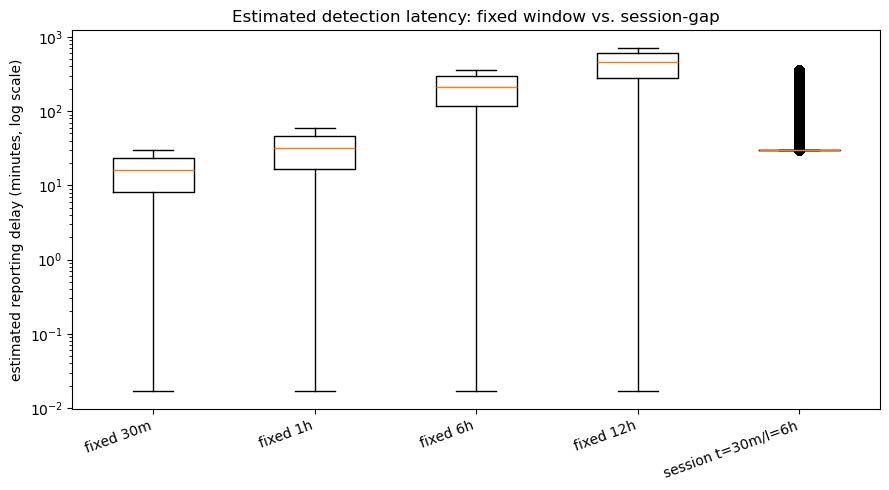

In [52]:
fig, ax = plt.subplots(figsize=(9, 5))
labels_ordered = list(delay_distributions.keys())
ax.boxplot(
    [delay_distributions[label] / 60 for label in labels_ordered],  # minutes
    tick_labels=labels_ordered,
    showfliers=True,
)
ax.set_ylabel('estimated reporting delay (minutes, log scale)')
ax.set_yscale('log')
ax.set_title('Estimated detection latency: fixed window vs. session-gap')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

## 14. Grouped Dataset — session-gap binning (`cscas_target_session`)

Same EDA as section 11 (`cscas_target_window`), applied to the session-gap scheme: baskets keyed by internal target IP, closed after a `session_timeout` quiet gap or forced closed at the `session_length` cap — see `group_cscas_rows_by_target_session` in `src/thesis/grouping/group_alerts.py`.

In [53]:
# Pick one session-gap cache to inspect in detail (defaults to the one used in section 13;
# falls back to whichever was discovered if that exact combo isn't present).
_default_session_key = (1800.0, 21600.0)
session_key = _default_session_key if _default_session_key in session_caches else next(iter(session_caches))
session_path = session_caches[session_key]
print(f'Inspecting session-gap cache: timeout={session_key[0]:g}s, length={session_key[1]:g}s')
print(f'Path: {session_path}')

with open(session_path, 'r') as f:
    ts_groups = json.load(f)

print(f'Loaded {len(ts_groups)} session-gap alert_groups')

Inspecting session-gap cache: timeout=1800s, length=21600s
Path: ../../../artifacts/cache/cscas/groups/cscas_target_session_t1800s_l21600s/alert_groups/alert_groups_raw.json
Loaded 663612 session-gap alert_groups


In [54]:
ts_df = pd.DataFrame([
    {
        'group_id': g['group_id'],
        'int_ip': g['int_ip'],
        'n_alerts': g['n_alerts'],
        'n_rows': len(g['sorted_items']),
        'n_items': len(g['abs_items']),
        'group_label': g['group_label'],
        'start_ts': g['start_ts'],
        'end_ts': g['end_ts'],
    }
    for g in ts_groups
])

print(f'Baskets: {len(ts_df)}')
print(f'Distinct int_ip: {ts_df["int_ip"].nunique()}')
print()
print('group_label distribution:')
print(ts_df['group_label'].value_counts())
print()
print('n_rows (CSV rows aggregated per basket) — describe:')
print(ts_df['n_rows'].describe())

Baskets: 663612
Distinct int_ip: 4401

group_label distribution:
group_label
benign    655786
attack      4145
mixed       3681
Name: count, dtype: int64

n_rows (CSV rows aggregated per basket) — describe:
count    663612.000000
mean          1.604811
std           5.796407
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max         788.000000
Name: n_rows, dtype: float64


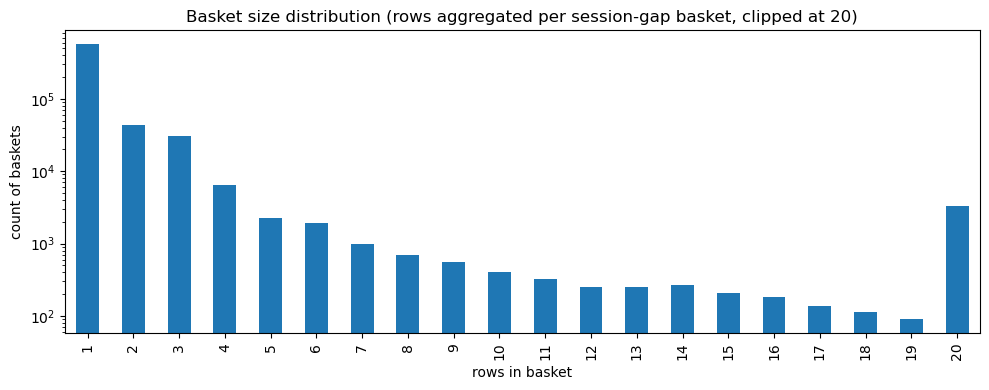

In [60]:
fig, ax = plt.subplots(figsize=(10, 4))
ts_df['n_rows'].clip(upper=20).value_counts().sort_index().plot(kind='bar', ax=ax)
ax.set_title('Basket size distribution (rows aggregated per session-gap basket, clipped at 20)')
ax.set_xlabel('rows in basket')
ax.set_ylabel('count of baskets')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

### Are session-gap baskets actually multi-signature, or just the same signature repeated?

Same check as section 11 for `cscas_target_window`: count distinct token-sets (i.e. distinct signatures) within each basket's `sorted_items`, not just row count.

In [56]:
ts_df['n_distinct_sigs'] = [n_distinct_signatures(g) for g in ts_groups]

ts_multi_row = ts_df[ts_df['n_rows'] > 1]
ts_diverse = ts_multi_row[ts_multi_row['n_distinct_sigs'] > 1]

print(f"Baskets with >1 row: {len(ts_multi_row)} ({len(ts_multi_row) / len(ts_df):.1%} of all baskets)")
print(f"Baskets genuinely spanning >1 distinct signature: {len(ts_diverse)} ({len(ts_diverse) / len(ts_df):.1%} of all baskets)")
print(f"  = {len(ts_diverse) / len(ts_multi_row):.1%} of multi-row baskets")
print()
print('Distribution of n_distinct_sigs among multi-row baskets:')
print(ts_multi_row['n_distinct_sigs'].value_counts().sort_index().head(15))

Baskets with >1 row: 92862 (14.0% of all baskets)
Baskets genuinely spanning >1 distinct signature: 53348 (8.0% of all baskets)
  = 57.4% of multi-row baskets

Distribution of n_distinct_sigs among multi-row baskets:
n_distinct_sigs
1     39514
2     33395
3     13349
4      3952
5      1319
6       590
7       252
8       128
9        63
10       31
11       12
12        8
13       31
14      117
15       46
Name: count, dtype: int64


### Cross-signature category co-occurrence (session-gap)

Same category-pair analysis as section 11, for the session-gap baskets.

In [57]:
ts_pair_counts = Counter()
for g in ts_groups:
    cats = set()
    for row_tokens in g['sorted_items']:
        cats.update(t for t in row_tokens if t.startswith('cat:'))
    if len(cats) >= 2:
        for pair in combinations(sorted(cats), 2):
            ts_pair_counts[pair] += 1

ts_n_total = len(ts_groups)
ts_top_pairs = pd.DataFrame(
    [(a, b, c, c / ts_n_total) for (a, b), c in ts_pair_counts.most_common(20)],
    columns=['category_a', 'category_b', 'count', 'support'],
)
ts_top_pairs

,category_a,category_b,count,support
0,cat:EXPLOIT,cat:WEB_SERVER,20893,0.031484
1,cat:DNS,cat:SNMP,6298,0.009490
2,cat:DOS,cat:SNMP,6083,0.009167
3,cat:RPC,cat:SNMP,4592,0.006920
4,cat:EXPLOIT,cat:SNMP,2569,0.003871
5,cat:SNMP,cat:WEB_SERVER,2461,0.003708
6,cat:DNS,cat:DOS,1909,0.002877
7,cat:DOS,cat:RPC,1845,0.002780
8,cat:DNS,cat:RPC,1333,0.002009
9,cat:WEB_SERVER,cat:WEB_SPECIFIC_APPS,1195,0.001801


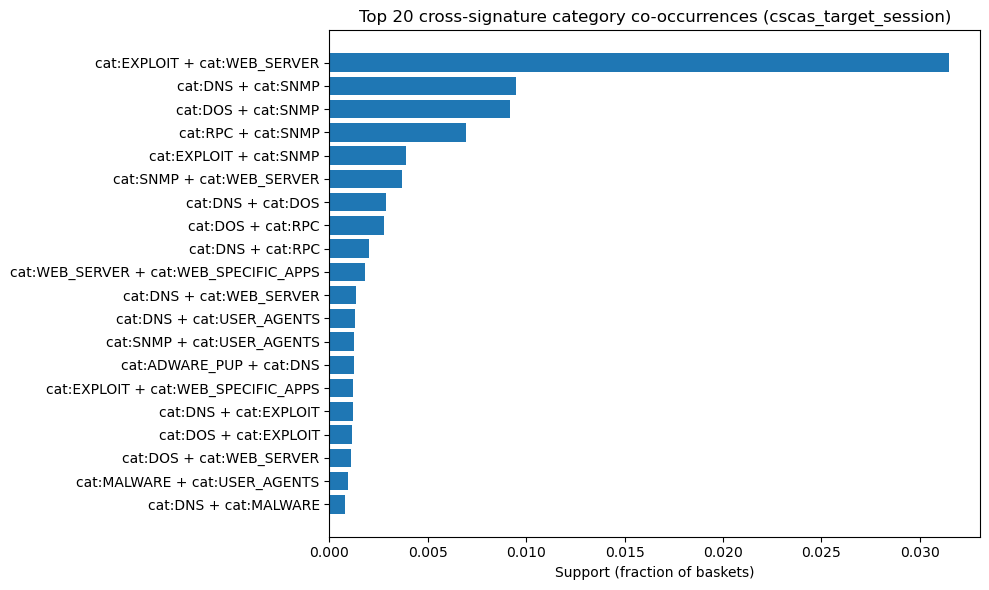

In [58]:
fig, ax = plt.subplots(figsize=(10, 6))
ts_labels = [f"{a} + {b}" for a, b in zip(ts_top_pairs['category_a'], ts_top_pairs['category_b'])]
ax.barh(ts_labels[::-1], ts_top_pairs['support'].values[::-1])
ax.set_xlabel('Support (fraction of baskets)')
ax.set_title('Top 20 cross-signature category co-occurrences (cscas_target_session)')
plt.tight_layout()
plt.show()

In [59]:
# Eyeball one genuinely multi-signature session-gap basket
ts_diverse_groups = [g for g in ts_groups if n_distinct_signatures(g) > 1]
ts_sample = ts_diverse_groups[0]

print('int_ip:', ts_sample['int_ip'])
print('label:', ts_sample['group_label'])
print('n_rows:', len(ts_sample['sorted_items']))
print('duration (s):', ts_sample['end_ts'] - ts_sample['start_ts'])
print('abs_items (union):', sorted(ts_sample['abs_items']))
print()
print('sorted_items (one row per original signature, timestamp order):')
for row_tokens in ts_sample['sorted_items']:
    print(' -', sorted(row_tokens))

int_ip: intip3
label: benign
n_rows: 3
duration (s): 0
abs_items (union): ['administration', 'administration_protocol', 'bypass', 'cat:EXPLOIT', 'cat:WEB_SERVER', 'command', 'command_execution', 'command_specifying', 'devices', 'devices_home', 'execution', 'headers', 'hnap', 'hnap_protocol', 'home', 'home_network', 'http', 'http_headers', 'link', 'link_devices', 'link_router', 'network', 'network_administration', 'output', 'output_http', 'protocol', 'protocol_command', 'protocol_security', 'qual:possible', 'router', 'router_hnap', 'security', 'security_bypass', 'specifying', 'specifying_output', 'wget', 'wget_command']

sorted_items (one row per original signature, timestamp order):
 - ['administration', 'administration_protocol', 'cat:EXPLOIT', 'command', 'command_execution', 'devices', 'devices_home', 'execution', 'home', 'home_network', 'link', 'link_devices', 'network', 'network_administration', 'protocol', 'protocol_command']
 - ['cat:WEB_SERVER', 'command', 'command_specifying', 